# Exploratory data analysis

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from importDataset import importBigQuerry

In [2]:
df = importBigQuerry()

c:\Users\antoi\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  Int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  Int64  
 6   duration_ms       114000 non-null  Int64  
 7   explicit          114000 non-null  boolean
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  Int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  Int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

## Dataset overview

In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,18172,3iypHvZowqXC9DYrsz8h14,"""Weird Al"" Yankovic",Poodle Hat,Genius In France,26,536786,False,0.560,0.560,...,-11.478,1,0.0980,0.04130,0.000000,0.2310,0.688,135.939,4,comedy
1,105106,4ufMIn7ee8xlsAePOf22r8,$affie,summertime,summertime,39,134506,False,0.744,0.178,...,-13.225,1,0.0996,0.80800,0.890000,0.0960,0.230,148.260,4,study
2,107494,7AVStC1F1T427ecPjvMKXX,'Til Tuesday,Coming Up Close: A Retrospective,Voices Carry - Single Mix,28,261266,False,0.611,0.645,...,-7.394,1,0.0264,0.00339,0.000004,0.0793,0.411,106.639,4,synth-pop
3,58456,5pPfqZ8yDJXhmSPaZO9Ir7,(Hed) P.E.,Broke,I Got You,25,222226,False,0.636,0.871,...,-5.354,1,0.0732,0.00559,0.000001,0.1440,0.504,95.060,4,industrial
4,58873,76VRffkkxp3x2is62vEOx6,(Hed) P.E.,Insomnia,Madhouse,22,125706,True,0.679,0.774,...,-9.305,1,0.1320,0.15500,0.000000,0.9250,0.163,137.019,4,industrial


In [5]:
df.describe(include='all')

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,114000.0,114000,113999,113999,113999,114000.0,114000.0,114000,114000.000000,114000.000000,...,114000.000000,114000.0,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.0,114000
unique,<NA>,89741,31437,46589,73608,<NA>,<NA>,2,NaN,NaN,...,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,114
top,<NA>,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,<NA>,<NA>,False,NaN,NaN,...,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,comedy
freq,<NA>,9,279,195,151,<NA>,<NA>,104253,NaN,NaN,...,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,1000
mean,56999.5,NaN,NaN,NaN,NaN,33.238535,228029.153114,NaN,0.566800,0.641383,...,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,NaN
std,32909.109681,NaN,NaN,NaN,NaN,22.305078,107297.712645,NaN,0.173542,0.251529,...,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,NaN
min,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.000000,0.000000,...,-49.531000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,NaN
25%,28499.75,NaN,NaN,NaN,NaN,17.0,174066.0,NaN,0.456000,0.472000,...,-10.013000,0.0,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.0,NaN
50%,56999.5,NaN,NaN,NaN,NaN,35.0,212906.0,NaN,0.580000,0.685000,...,-7.004000,1.0,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.0,NaN
75%,85499.25,NaN,NaN,NaN,NaN,50.0,261506.0,NaN,0.695000,0.854000,...,-5.003000,1.0,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.0,NaN


In [6]:
df.nunique()

Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46589
track_name           73608
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness          5061
instrumentalness      5346
liveness              1722
valence               1790
tempo                45653
time_signature           5
track_genre            114
dtype: int64

In [7]:
df[df.isna().any(axis=1)]
# Since there is only 1 observations where artists, album_name and track_name are missing, and the number of observations is huge
# with respect to the number of missing values, we can consistently delete this observation.

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65344,65900,1kR4gIb7nGxHPI3D2ifs59,None,None,None,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


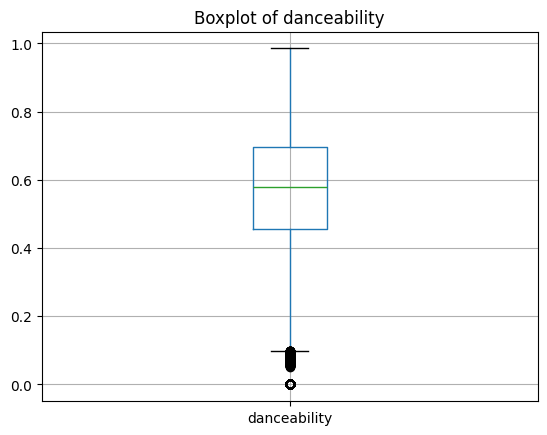

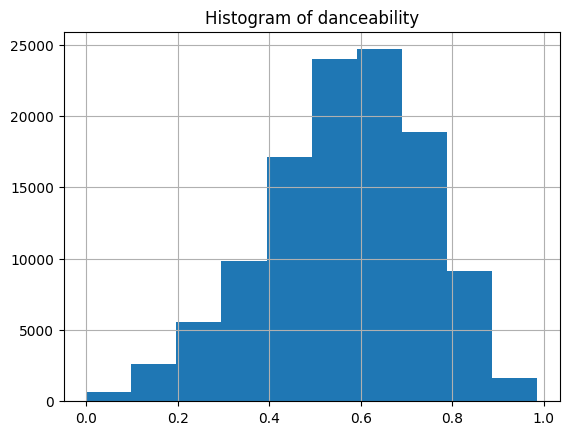

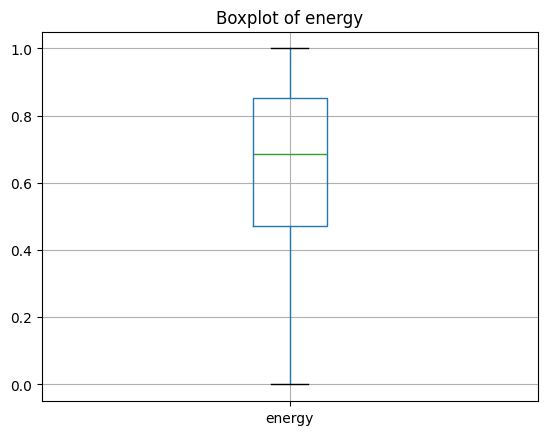

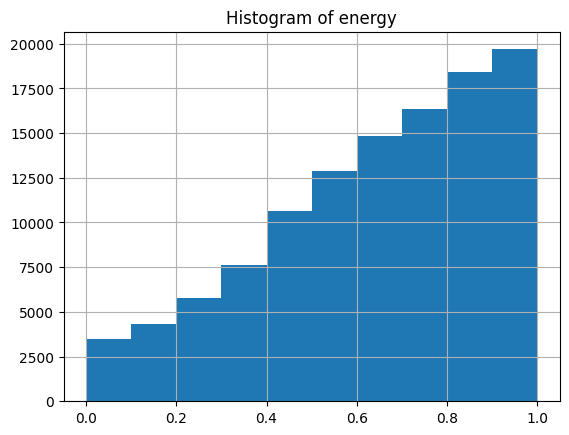

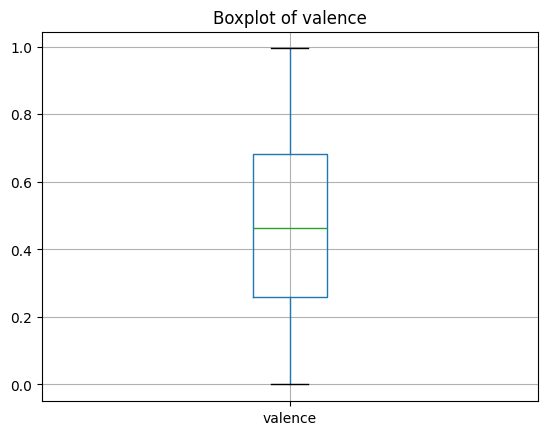

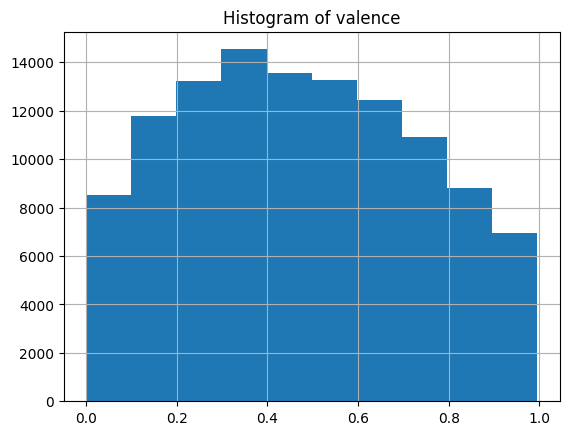

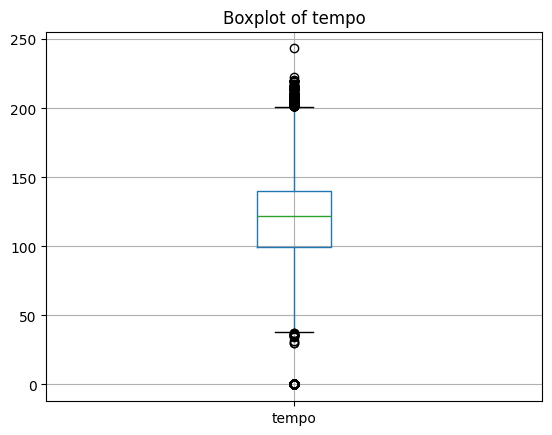

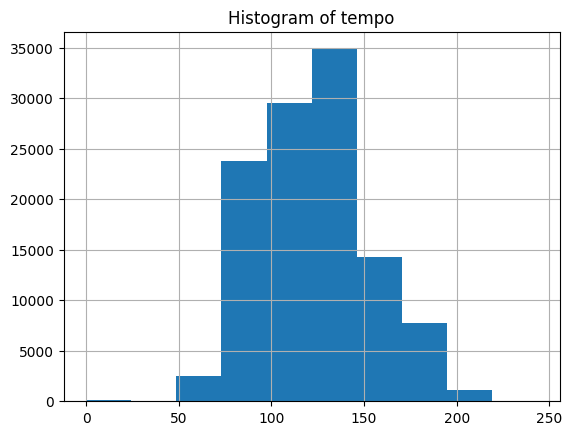

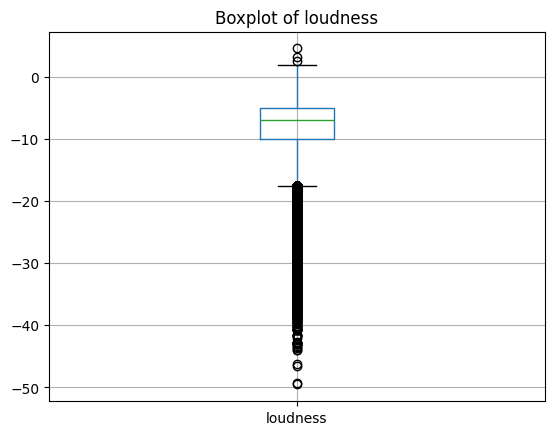

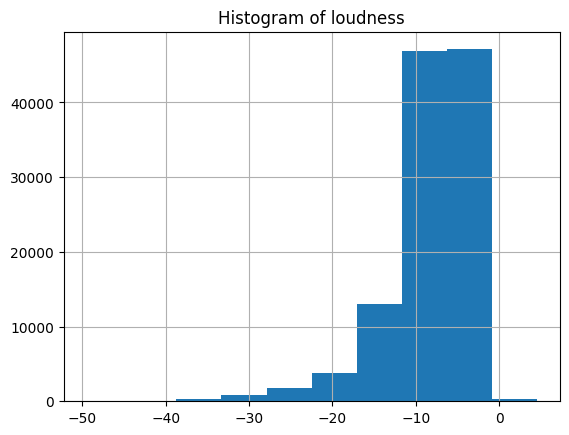

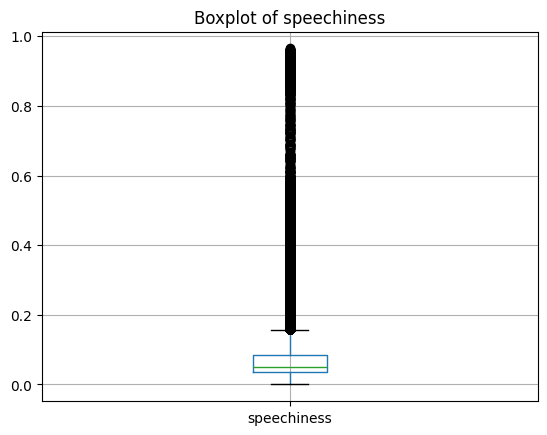

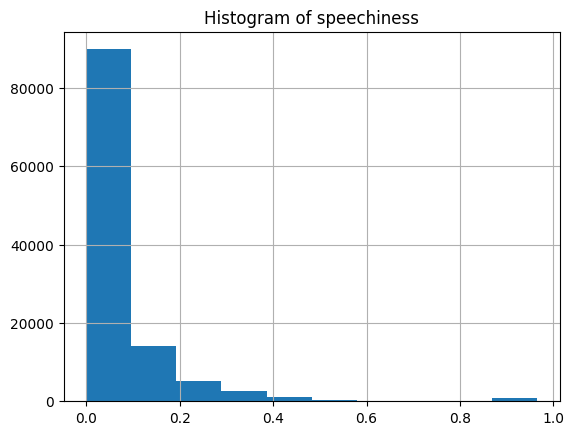

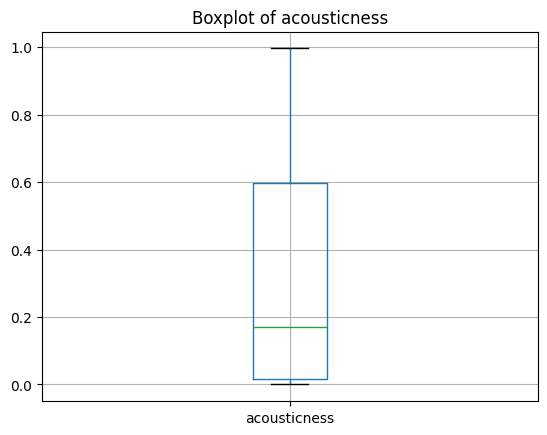

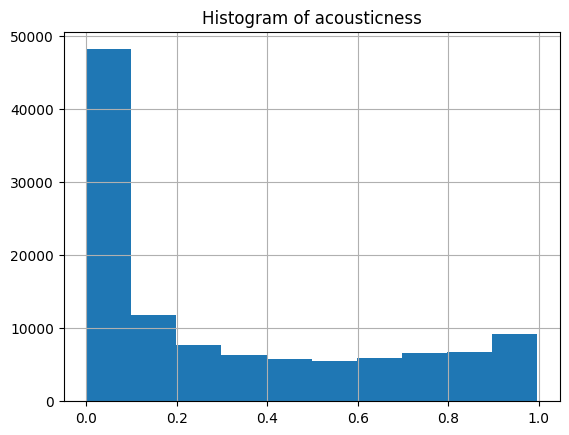

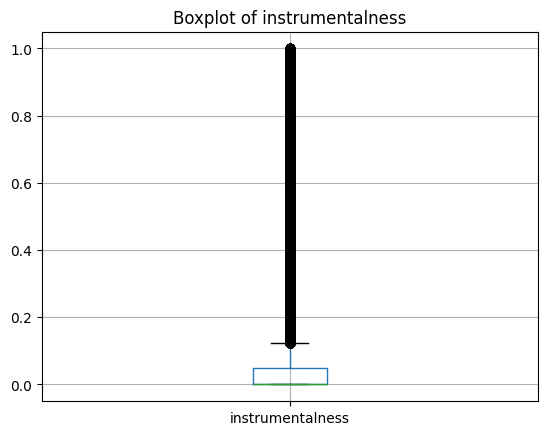

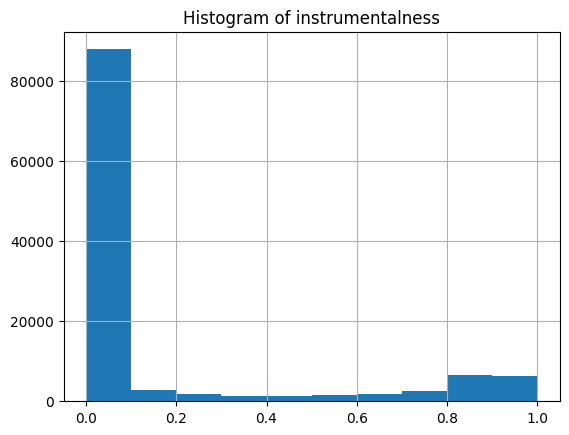

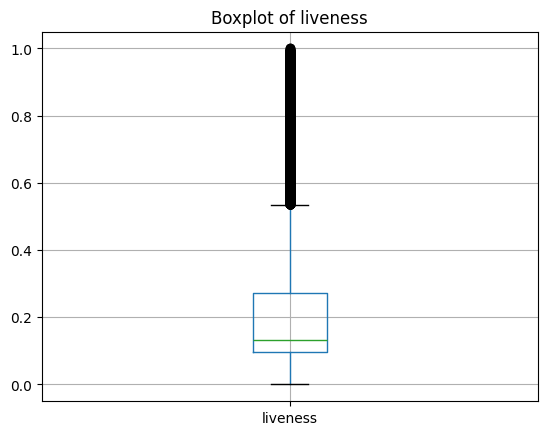

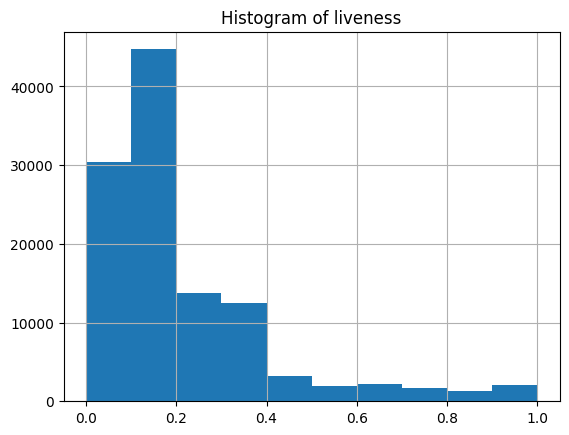

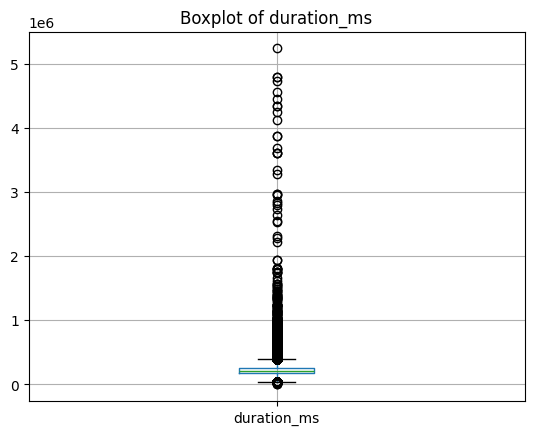

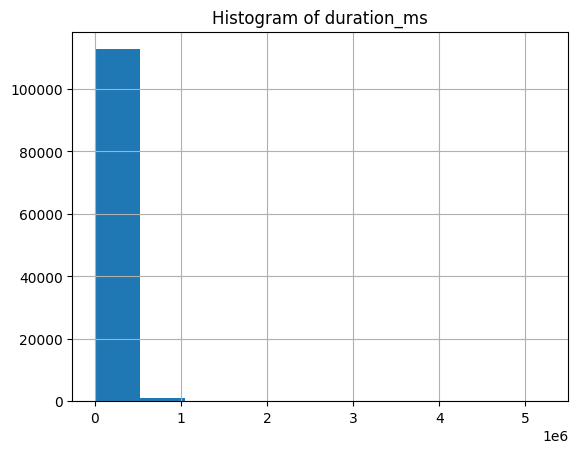

In [8]:
for i in ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'acousticness',
          'instrumentalness', 'liveness', 'duration_ms']:
    df.boxplot(column=i)
    plt.title("Boxplot of "+i)
    plt.show()
    df.hist(column=i)
    plt.title("Histogram of "+i)
    plt.show()

## Correlation analysis

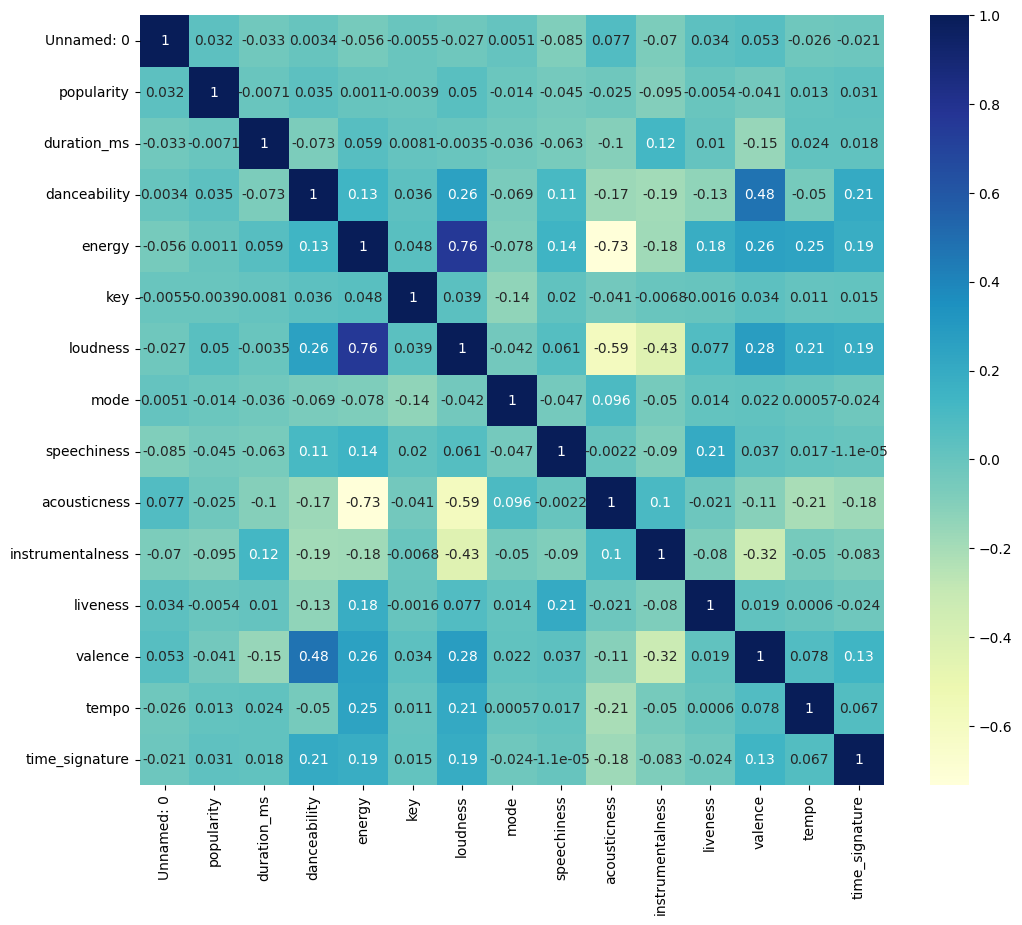

In [9]:
datacorr = df.select_dtypes(include='number')
plt.figure(figsize=(12, 10))
sns.heatmap(datacorr.corr(), cmap="YlGnBu", annot=True)
plt.savefig("../../docs/figures/Correlation plot.pdf")
plt.show()

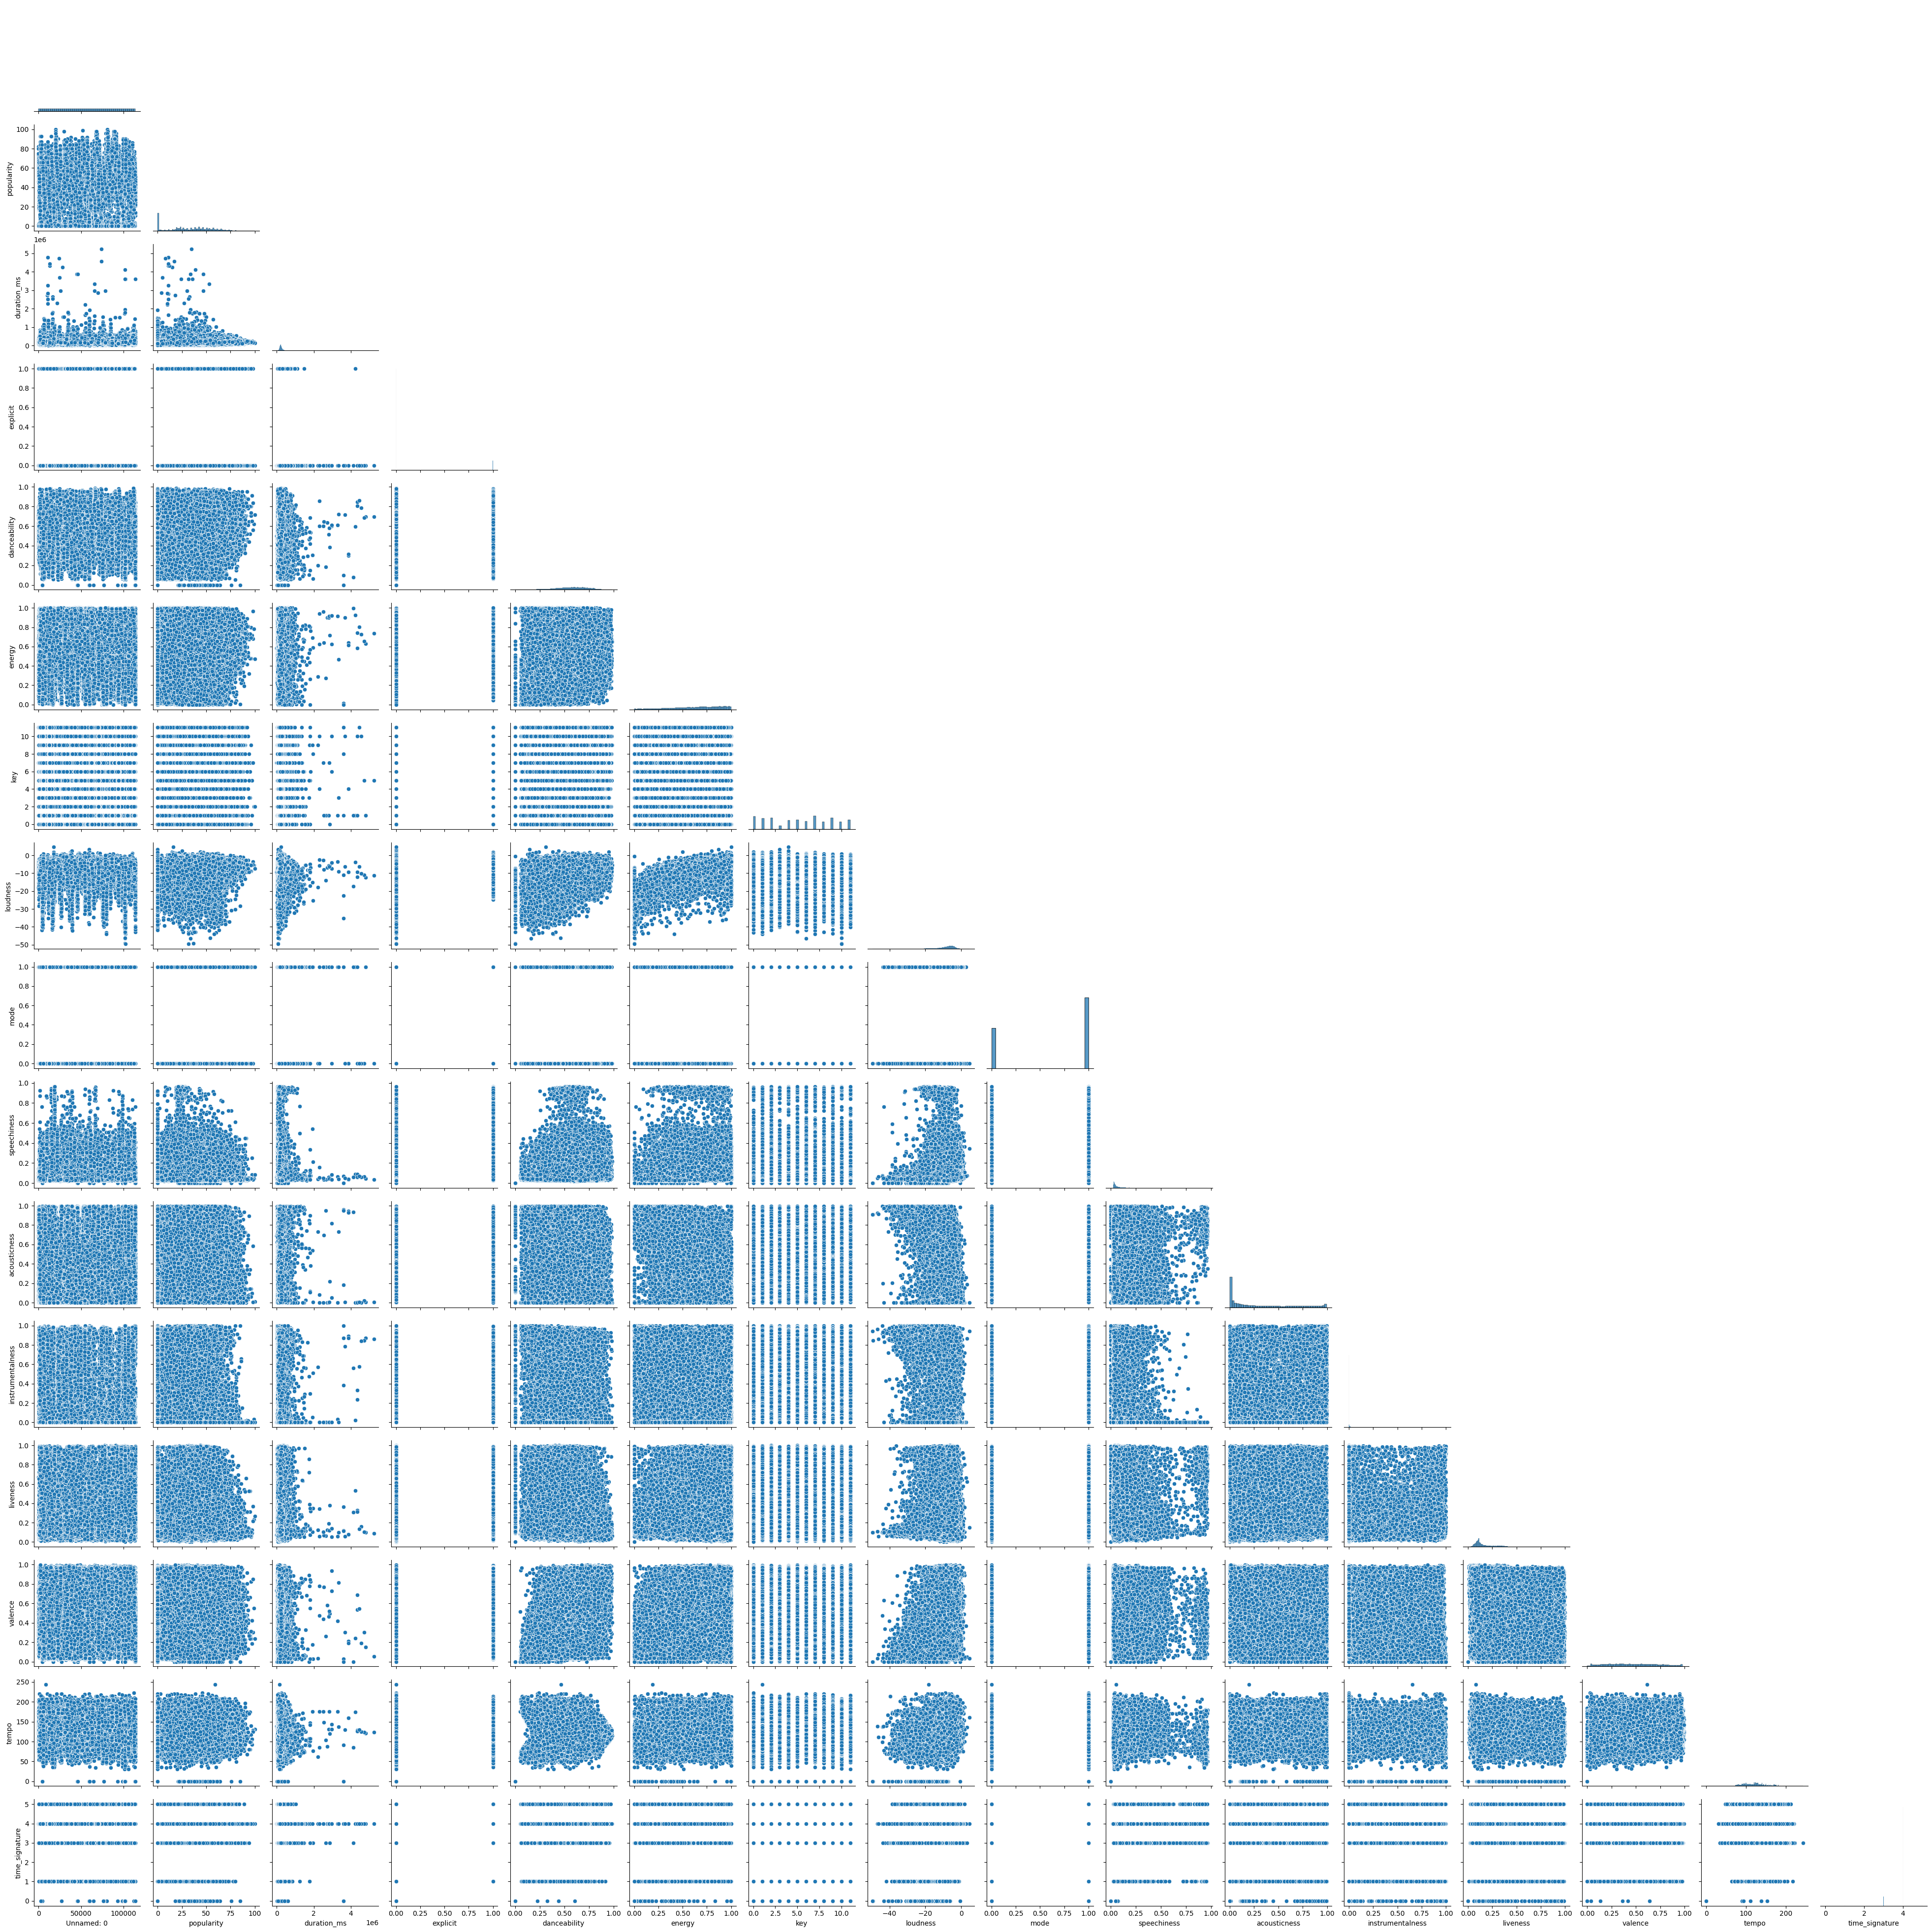

In [10]:
sns.pairplot(df, kind='scatter', corner=True)
plt.show()

## PCA

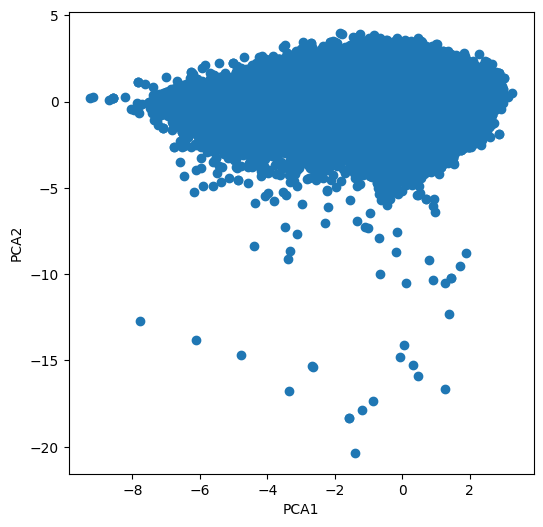

In [11]:
selectionPCA = ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'duration_ms']

data = df[selectionPCA]

scaler = StandardScaler()
dataScaled = scaler.fit_transform(data)

pca2D = PCA(n_components=2)
data2D = pca2D.fit_transform(dataScaled)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)

ax.scatter(data2D[:, 0], data2D[:, 1])
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
fig.savefig("../../docs/figures/PCA2D.pdf")
fig

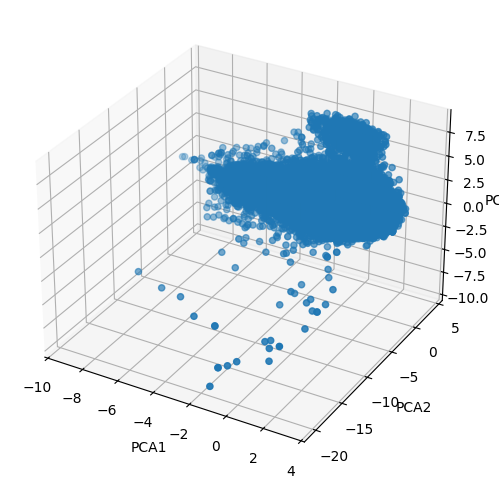

In [12]:
pca3D = PCA(n_components=3)
data3D = pca3D.fit_transform(dataScaled)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection="3d")

ax.scatter(data3D[:, 0], data3D[:, 1], data3D[:, 2])
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
fig.savefig("../../docs/figures/PCA3D.pdf")
fig

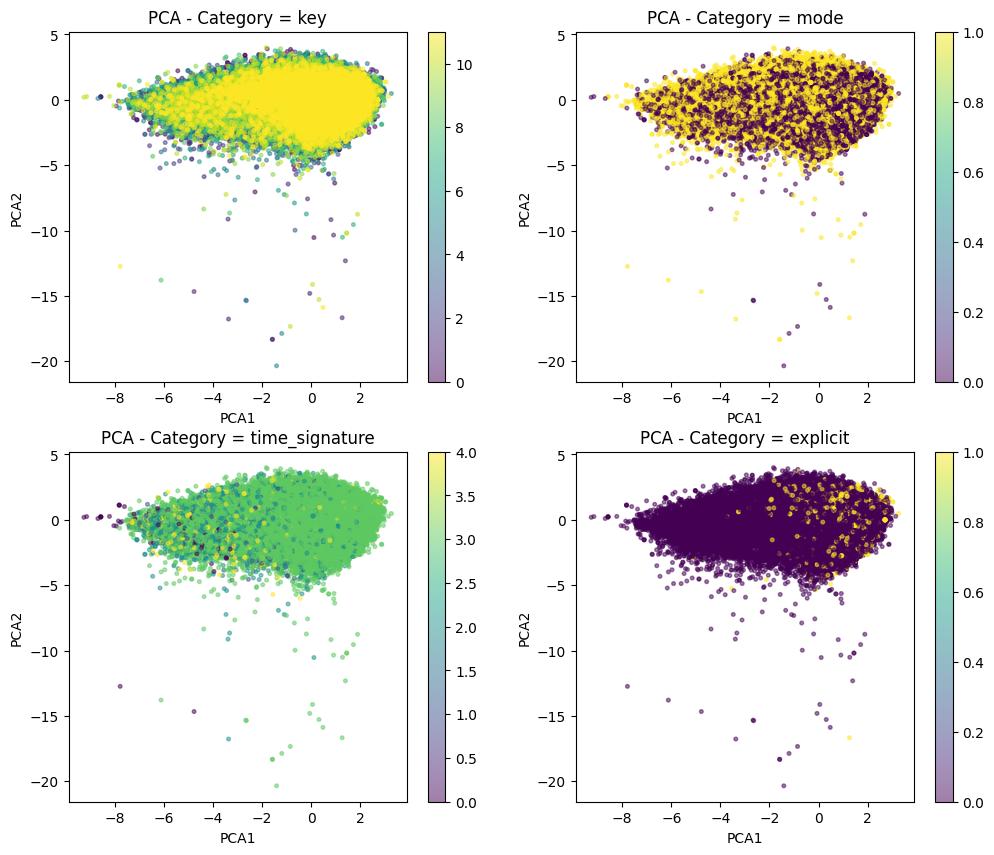

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sc = axes[0, 0].scatter(data2D[:, 0], data2D[:, 1], c=df['key'].astype(
    'category').cat.codes, s=7, alpha=0.5)
axes[0, 0].set_title("PCA - Category = key")
axes[0, 0].set_xlabel("PCA1")
axes[0, 0].set_ylabel("PCA2")

plt.colorbar(sc, ax=axes[0, 0])

sc = axes[0, 1].scatter(data2D[:, 0], data2D[:, 1], c=df['mode'].astype(
    'category').cat.codes, s=7, alpha=0.5)
axes[0, 1].set_title("PCA - Category = mode")
axes[0, 1].set_xlabel("PCA1")
axes[0, 1].set_ylabel("PCA2")

plt.colorbar(sc, ax=axes[0, 1])

sc = axes[1, 0].scatter(data2D[:, 0], data2D[:, 1], c=df['time_signature'].astype(
    'category').cat.codes, s=7, alpha=0.5)
axes[1, 0].set_title("PCA - Category = time_signature")
axes[1, 0].set_xlabel("PCA1")
axes[1, 0].set_ylabel("PCA2")

plt.colorbar(sc, ax=axes[1, 0])

sc = axes[1, 1].scatter(data2D[:, 0], data2D[:, 1], c=df['explicit'].astype(
    'category').cat.codes, s=7, alpha=0.5)
axes[1, 1].set_title("PCA - Category = explicit")
axes[1, 1].set_xlabel("PCA1")
axes[1, 1].set_ylabel("PCA2")

plt.colorbar(sc, ax=axes[1, 1])
fig.savefig("../../docs/figures/PCA categories.pdf")
fig

In [14]:
print(pca3D.explained_variance_ratio_)
print(pca2D.explained_variance_ratio_)

[0.28738924 0.15239652 0.12340209]
[0.28738924 0.15239652]


In [15]:
df["hit"] = (df["popularity"] >= 65).astype(int)
df = df.drop(columns=["popularity"])
df["hit"].describe()

count    114000.000000
mean          0.083132
std           0.276082
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: hit, dtype: float64

In [16]:
df["hit"].sum()

np.int64(9477)

In [21]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

categories = ["duration_ms", "danceability", "energy", "key", "loudness"]

# Normaliser entre 0 et 1
scaler = MinMaxScaler()
df_scaled = df[categories].copy()
df_scaled[categories] = scaler.fit_transform(df[categories])

# Extraire l'observation 46
values = df_scaled.iloc[46][categories].tolist()

# Fermer le polygone
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

# Tracé
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))
ax.fill(angles, values, color='green', alpha=0.4)
ax.plot(angles, values, color='green', linewidth=2)
ax.set_xticks(angles[:N])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title(f"Observation 46 : {df.iloc[46]['track_name']}", pad=20)

plt.tight_layout()
plt.savefig("../../docs/figures/testRadar.pdf")